# Домашнее задание "Продвинутая линейная алгебра".

## Уровень 0:


### Задание 1

Дан объект в $2D$ пространстве

(-200.0, 200.0)

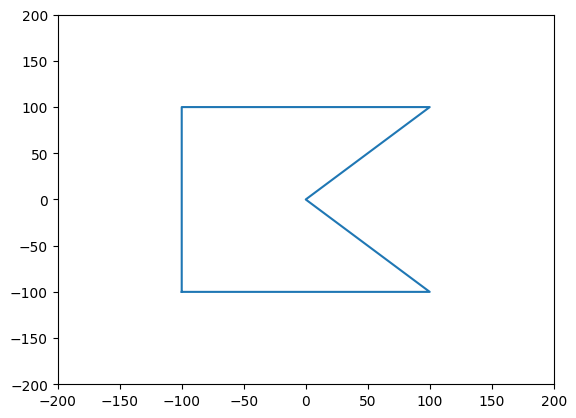

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

A = [
[-100, -100, 1],
[-100, 100, 1],
[100, 100, 1],
[0, 0, 1],
[100, -100, 1],
[-100, -100, 1]
]

A = np.array(A)

x = A[:,0]
y = A[:,1]
plt.plot(x, y)
plt.ylim([-200, 200])
plt.xlim([-200, 200])

При помощи линейных отображений:
- Уменьшить объект в два раза
- Повернуть на 130 градусов
- Отразить объект относительно прямой y=x (поможет матрица `[[0, 1, 0], [1, 0, 0], [0, 0, 1]]`)


а) Уменьшение объекта в 2 раза

In [ ]:
# применим к объекту линейный оператор В1 - диагональную матрицу
B1 = np.array([[0.5, 0, 0], [0, 0.5, 0], [0, 0, 0.5]])
B1

array([[0.5, 0. , 0. ],
       [0. , 0.5, 0. ],
       [0. , 0. , 0.5]])

In [ ]:
# транспонируем А, чтоб она совпадала по размерности с В и перемножаем
res = B1 @ A.transpose()
res

array([[-50. , -50. ,  50. ,   0. ,  50. , -50. ],
       [-50. ,  50. ,  50. ,   0. , -50. , -50. ],
       [  0.5,   0.5,   0.5,   0.5,   0.5,   0.5]])

In [ ]:
# полученный результат транспонируем обратно, чтоб его можно было графически отобразить
A1 = res.transpose()
A1

array([[-50. , -50. ,   0.5],
       [-50. ,  50. ,   0.5],
       [ 50. ,  50. ,   0.5],
       [  0. ,   0. ,   0.5],
       [ 50. , -50. ,   0.5],
       [-50. , -50. ,   0.5]])

(-200.0, 200.0)

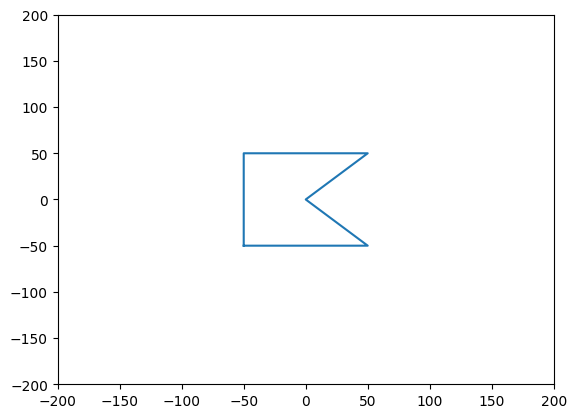

In [ ]:
# визуализация уменьшенного в 2 раза объекта

x = A1[:,0]
y = A1[:,1]
plt.plot(x, y)
plt.ylim([-200, 200])
plt.xlim([-200, 200])

б) Отражение объекта относительно прямой y=x

In [ ]:
# применим к объекту линейный оператор В2
B2 = np.array([[0, 1, 0], [1, 0, 0], [0, 0, 1]])
B2

array([[0, 1, 0],
       [1, 0, 0],
       [0, 0, 1]])

In [ ]:
# далее проделаем то же самое, что в пункте а)
res = B2 @ A.transpose()

A2 = res.transpose()

(-200.0, 200.0)

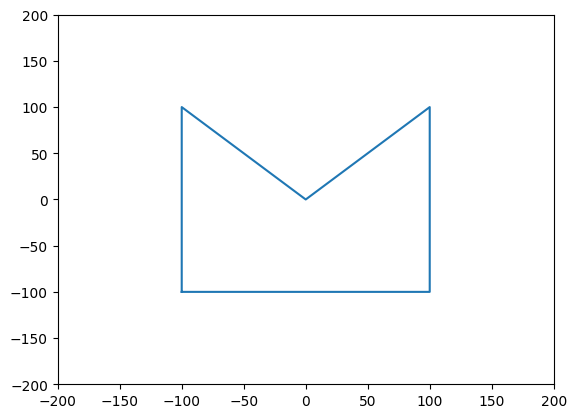

In [ ]:
# визуализация отраженного по прямой у=х объекта
x = A2[:,0]
y = A2[:,1]
plt.plot(x, y)
plt.ylim([-200, 200])
plt.xlim([-200, 200])

в) поворот на 130 градусов

In [ ]:
theta = np.radians(130)
cos_t = np.cos(theta)
sin_t = np.sin(theta)

In [ ]:
# применим к объекту линейный оператор В3
B3 = np.array([
    [cos_t, -sin_t, 0],
    [sin_t,  cos_t, 0],
    [0,      0,     1]
])
B3

array([[-0.64278761, -0.76604444,  0.        ],
       [ 0.76604444, -0.64278761,  0.        ],
       [ 0.        ,  0.        ,  1.        ]])

In [ ]:
# далее проделаем то же самое, что в пункте а)
res = B3 @ A.transpose()

A3 = res.transpose()

(-200.0, 200.0)

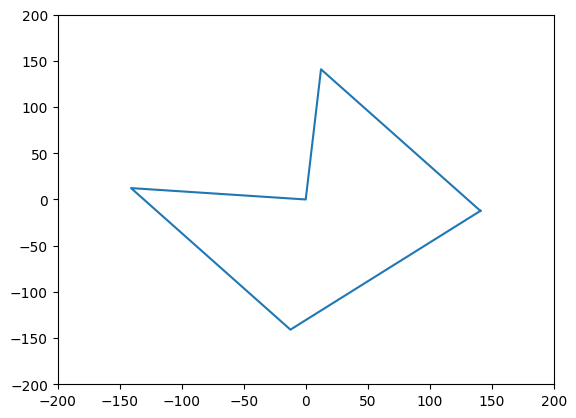

In [ ]:
# визуализация поворота на 130 градусов
x = A3[:,0]
y = A3[:,1]
plt.plot(x, y)
plt.ylim([-200, 200])
plt.xlim([-200, 200])

## Уровень 1:

### Задание 2

Найдите спектральное разложение матрицы:
```
m = np.array([[1, 2],
              [2, 3]])
print(m)
```



In [ ]:
m = np.array([[1, 2],
              [2, 3]])
print(m)

[[1 2]
 [2 3]]


In [ ]:
# находим собственные значения и собственные векторы
np.linalg.eig(m)

EigResult(eigenvalues=array([-0.23606798,  4.23606798]), eigenvectors=array([[-0.85065081, -0.52573111],
       [ 0.52573111, -0.85065081]]))

In [ ]:
# вытащим собственные значения
eigenvalues = np.linalg.eig(m)[0]
eigenvalues

array([-0.23606798,  4.23606798])

In [ ]:
# вытащим собственные векторы
eigenvectors = np.linalg.eig(m)[1]
eigenvectors

array([[-0.85065081, -0.52573111],
       [ 0.52573111, -0.85065081]])

In [ ]:
# диагональная матрица D с собственными значениями матрицы m на главной диагонали
D = np.diag(eigenvalues)
D

array([[-0.23606798,  0.        ],
       [ 0.        ,  4.23606798]])

In [ ]:
# ортогональная матрица S, столбы которой - собственные векторы матрицы m
# ВАЖНО: на этом шаге не транспонируем S, берем СВ в том же виде, что и получили ранее
S = eigenvectors
S

array([[-0.85065081, -0.52573111],
       [ 0.52573111, -0.85065081]])

In [ ]:
# транспонированная матрица St
St = S.T
St

array([[-0.85065081,  0.52573111],
       [-0.52573111, -0.85065081]])

In [ ]:
# проверяем разложение m = S * D * St
m1 = S @ D @ St
print(m1)
# с помощью метода allclose (с допуском отклонений rtol=1e-05, atol=1e-08)
print(np.allclose(m, m1))

[[1. 2.]
 [2. 3.]]
True
